In [ ]:
import keras
from keras.models import Sequential
import tensorflow as tf
import keras as k
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as img
from PIL import Image
import seaborn as sns
from keras.layers import Dense,Conv2D,MaxPooling2D,BatchNormalization,Dropout,Flatten,InputLayer

In [ ]:
model_CNN=Sequential()
model_CNN.add(Conv2D(16,(3,3),input_shape=(32,32,3),activation='relu',padding="same"))
model_CNN.add(Conv2D(32,(3,3),activation="relu",padding="same"))
model_CNN.add(Conv2D(32,(3,3),activation="relu",padding="same"))
model_CNN.add(Dropout(0.3))
model_CNN.add(MaxPooling2D())
model_CNN.add(BatchNormalization())
model_CNN.add(Conv2D(64,(3,3),activation="relu",padding="same"))
model_CNN.add(Conv2D(128,(3,3),activation="relu",padding="same"))
model_CNN.add(Conv2D(128,(3,3),activation="relu",padding="same"))
model_CNN.add(Dropout(0.3))
model_CNN.add(MaxPooling2D())
model_CNN.add(BatchNormalization())
model_CNN.add(Conv2D(64,(3,3),activation="relu",padding="same"))
model_CNN.add(Conv2D(128,(3,3),activation="relu",padding="same"))
model_CNN.add(Conv2D(128,(3,3),activation="relu",padding="same"))
model_CNN.add(Dropout(0.3))
model_CNN.add(MaxPooling2D())
model_CNN.add(BatchNormalization())
model_CNN.add(Flatten())
model_CNN.add(Dense(10,activation="softmax"))

In [ ]:
model_CNN.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 571,146 (2.18 MB)

 Trainable params: 570,570 (2.18 MB)

 Non-trainable params: 576 (2.25 KB)

In [ ]:
optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001)
model_CNN.compile(optimizer=optimizer,loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [ ]:
es=keras.callbacks.EarlyStopping(monitor="val_loss",mode="min",patience=10)

In [ ]:
(x_train,y_train),(x_test,y_test)=k.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
hist=model_CNN.fit(x_train,y_train,batch_size=64,epochs=10,validation_split=0.2)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9433 - loss: 0.1720 - val_accuracy: 0.6850 - val_loss: 0.9874
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9478 - loss: 0.1563 - val_accuracy: 0.7259 - val_loss: 0.8604
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9497 - loss: 0.1537 - val_accuracy: 0.7070 - val_loss: 0.9194
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9527 - loss: 0.1392 - val_accuracy: 0.7052 - val_loss: 0.9452
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9522 - loss: 0.1402 - val_accuracy: 0.7139 - val_loss: 0.9188
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9617 - loss: 0.1172 - val_accuracy: 0.6532 - val_loss: 1.2212
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9635 - loss: 0.1149 - val_accuracy: 0.7117 - val_loss: 0.9757
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9635 - loss: 0.1088 - va

In [ ]:
model_CNN.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6651 - loss: 0.9439


[0.9499479532241821, 0.6620000004768372]

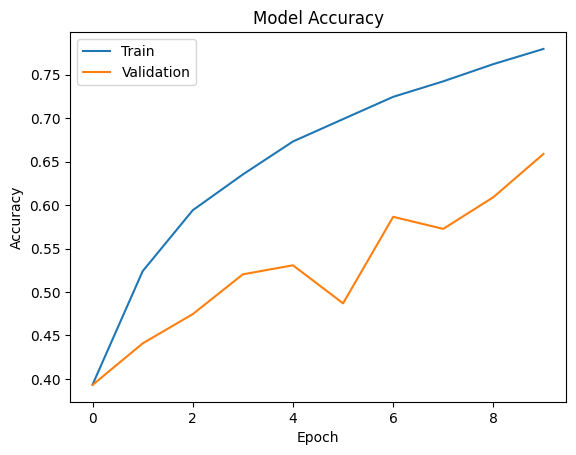

In [ ]:
plt.plot(hist.history["accuracy"],label="train")
plt.plot(hist.history["val_accuracy"],label="validation")
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train","Validation"],loc="upper left")
plt.show()

Text(0.5, 0, 'Epoch')

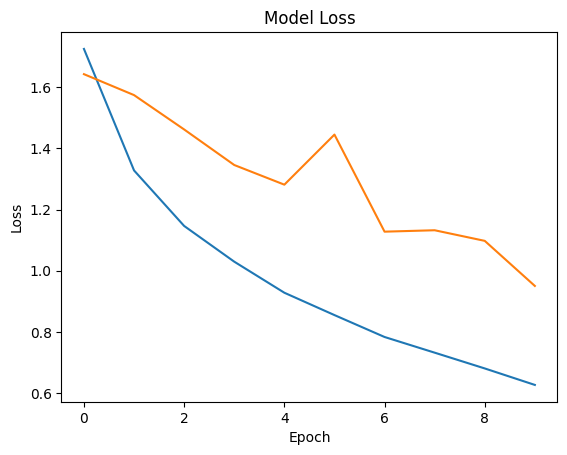

In [ ]:
plt.plot(hist.history["loss"],label="train")
plt.plot(hist.history["val_loss"],label="validation")
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")

In [ ]:
model_CNN.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6651 - loss: 0.9439


[0.9499479532241821, 0.6620000004768372]

In [ ]:
y_pred=model_CNN.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
